In [1]:
import os
#os.environ['PROJ_LIB'] = r'/home/fmg-wrf/anaconda3/pkgs/proj4-5.2.0-he6710b0_1/Library/share'
from netCDF4 import Dataset as NetCDFFile 
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap
import shapefile

In [2]:
nc = NetCDFFile(r"/home/fmg-wrf/Build_WRF/WRF_Run/run_WRF/wrfout_d01_2020-05-18_00:00:00")

In [3]:
map = Basemap(projection='merc',llcrnrlon=65.,llcrnrlat=10.,urcrnrlon=107.,urcrnrlat=35.,resolution='i')

/home/fmg-wrf/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: MatplotlibDeprecationWarning: 
The dedent function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use inspect.cleandoc instead.
  """Entry point for launching an IPython kernel.


In [4]:
rainc = nc.variables['RAINC']
rainnc = nc.variables['RAINNC']
rainsh = nc.variables['RAINSH']
time = nc.variables['XTIME']

In [5]:
#nOfDay = time.shape[0]

In [6]:
rainc

<class 'netCDF4._netCDF4.Variable'>
float32 RAINC(Time, south_north, west_east)
    FieldType: 104
    MemoryOrder: XY 
    description: ACCUMULATED TOTAL CUMULUS PRECIPITATION
    units: mm
    stagger: 
    coordinates: XLONG XLAT XTIME
unlimited dimensions: Time
current shape = (13, 159, 159)
filling on, default _FillValue of 9.969209968386869e+36 used

In [18]:
dataAll=[]
for r in range(4,13,4):
    z=(rainc[r,:,:]+rainnc[r,:,:]+rainsh[r,:,:]-rainc[r-4,:,:]-rainnc[r-4,:,:]-rainsh[r-4,:,:]).copy()
    #print(r)
    z[z<.01]=.01
    dataAll.append(z)

In [19]:
x=nc.variables['XLONG'][0][0]
y= nc.variables['XLAT'][0][:,0]


In [20]:
lons,lats= np.meshgrid(x,y)

In [21]:
len(dataAll)

3

In [22]:
x,y = map(lons,lats)

In [23]:
shapeFile=r"/home/fmg-wrf/Build_WRF/Software/ShapeFile/World_Countries"

In [24]:
dataAll[0].shape

(159, 159)

/home/fmg-wrf/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: MatplotlibDeprecationWarning: 
The dedent function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use inspect.cleandoc instead.
  after removing the cwd from sys.path.


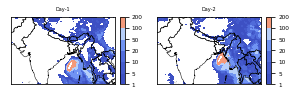

In [26]:
q=1
for p in dataAll[:-1]:
    plt.subplot(1,3,q)
    map.readshapefile(shapeFile,name="world") #map.drawcountries()#map.drawcoastlines()
    temp = map.contourf(x,y,p,[1, 5, 10, 20, 50, 100, 200],cmap='coolwarm')
    cb = map.colorbar(mappable=temp,location="right", size="5%", pad="5%")
    cb.ax.tick_params(labelsize='xx-small')
    plt.title('Day-'+str(q), fontsize=5)
    q=q+1
    #cb.set_label('rainc (m)')
    
plt.tight_layout()
plt.savefig('rainc2.png', dpi=300)

In [3]:
pwd

'C:\\Users\\ASUS'